# Experiment 2 - Email Spam/Ham Classification using Naive Bayes and KNN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy.stats import randint
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier

sns.set(style="whitegrid")

df = pd.read_csv("spambase_csv.csv")
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## Exploratory Data Analysis

EXPLORATORY DATA ANALYSIS

Target Column : class

Dataset Shape
(4601, 58)

Column Names
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_fr

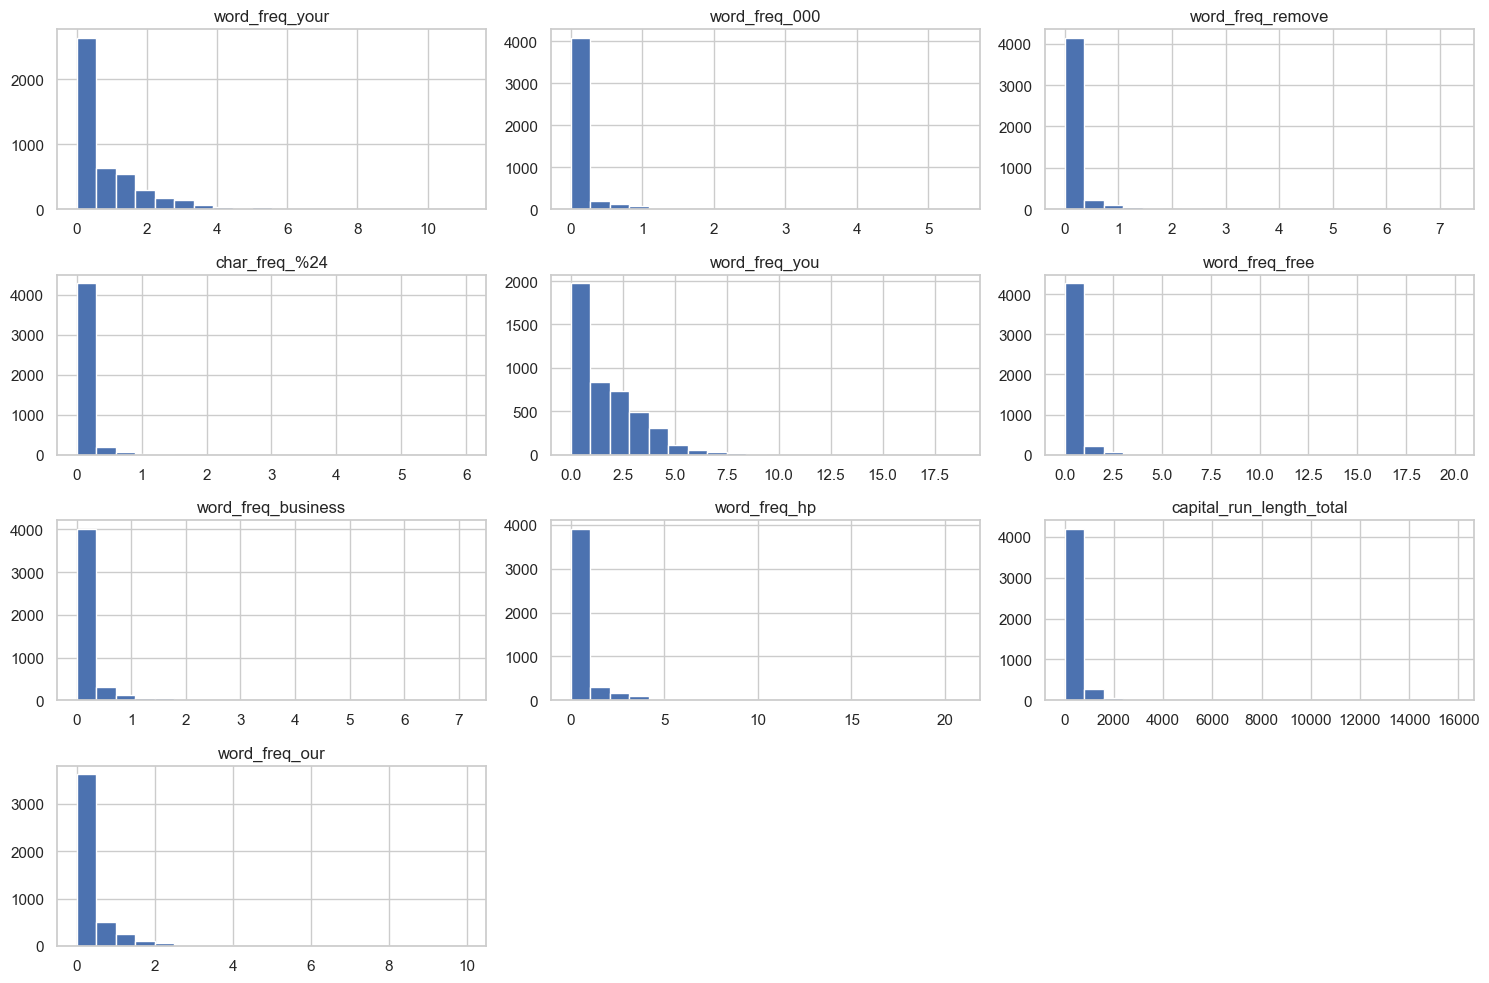


Outlier Detection


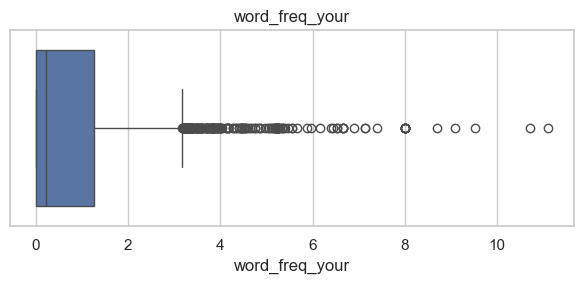

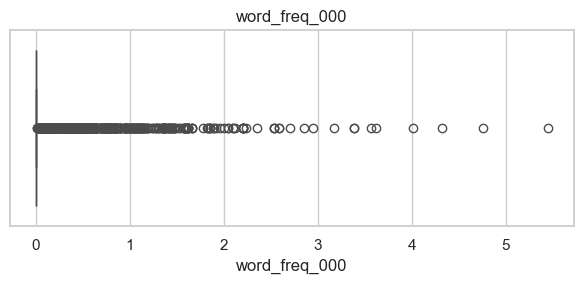

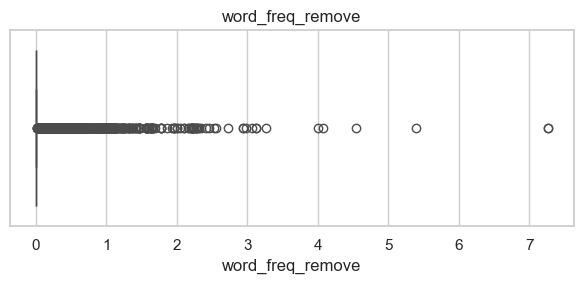

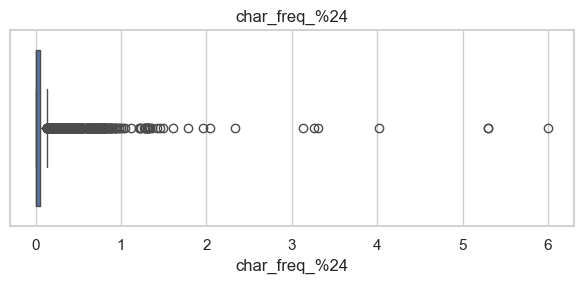

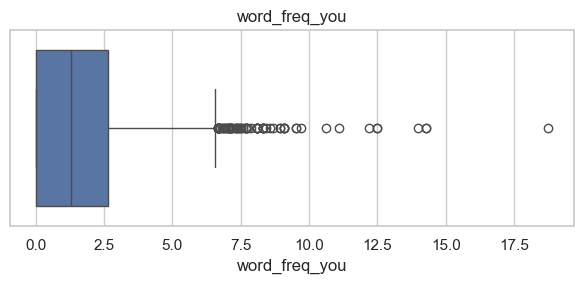

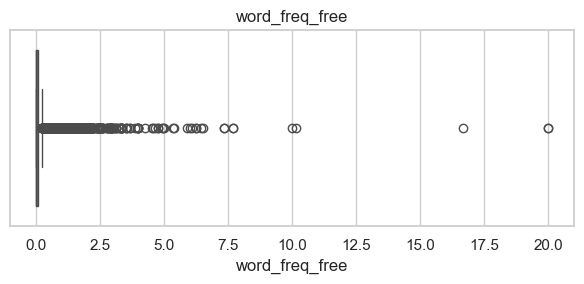

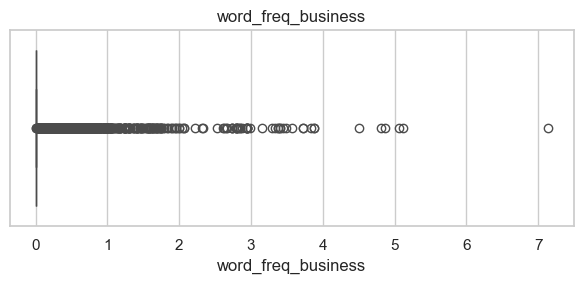

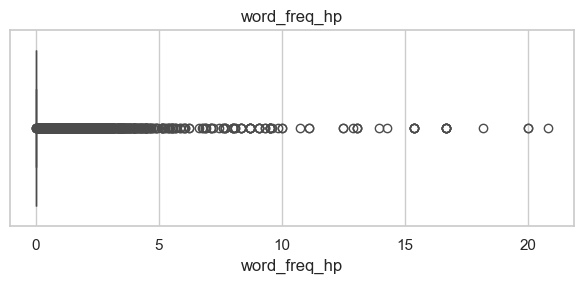

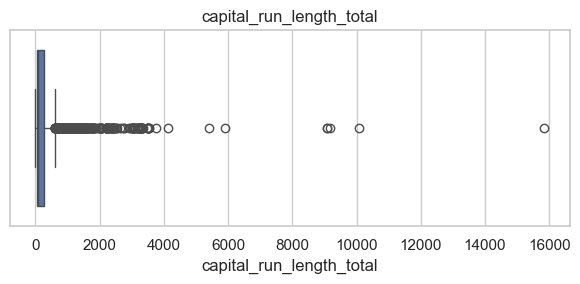

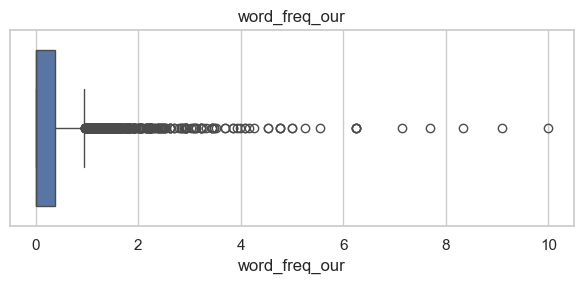


Correlation Heatmap


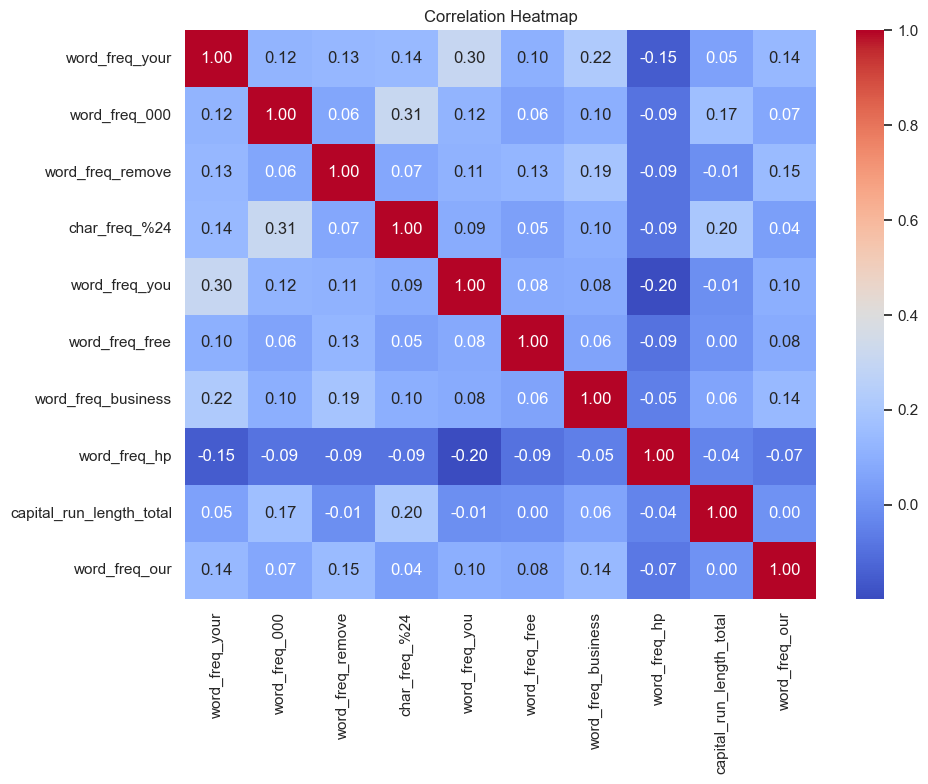


Pair Plot


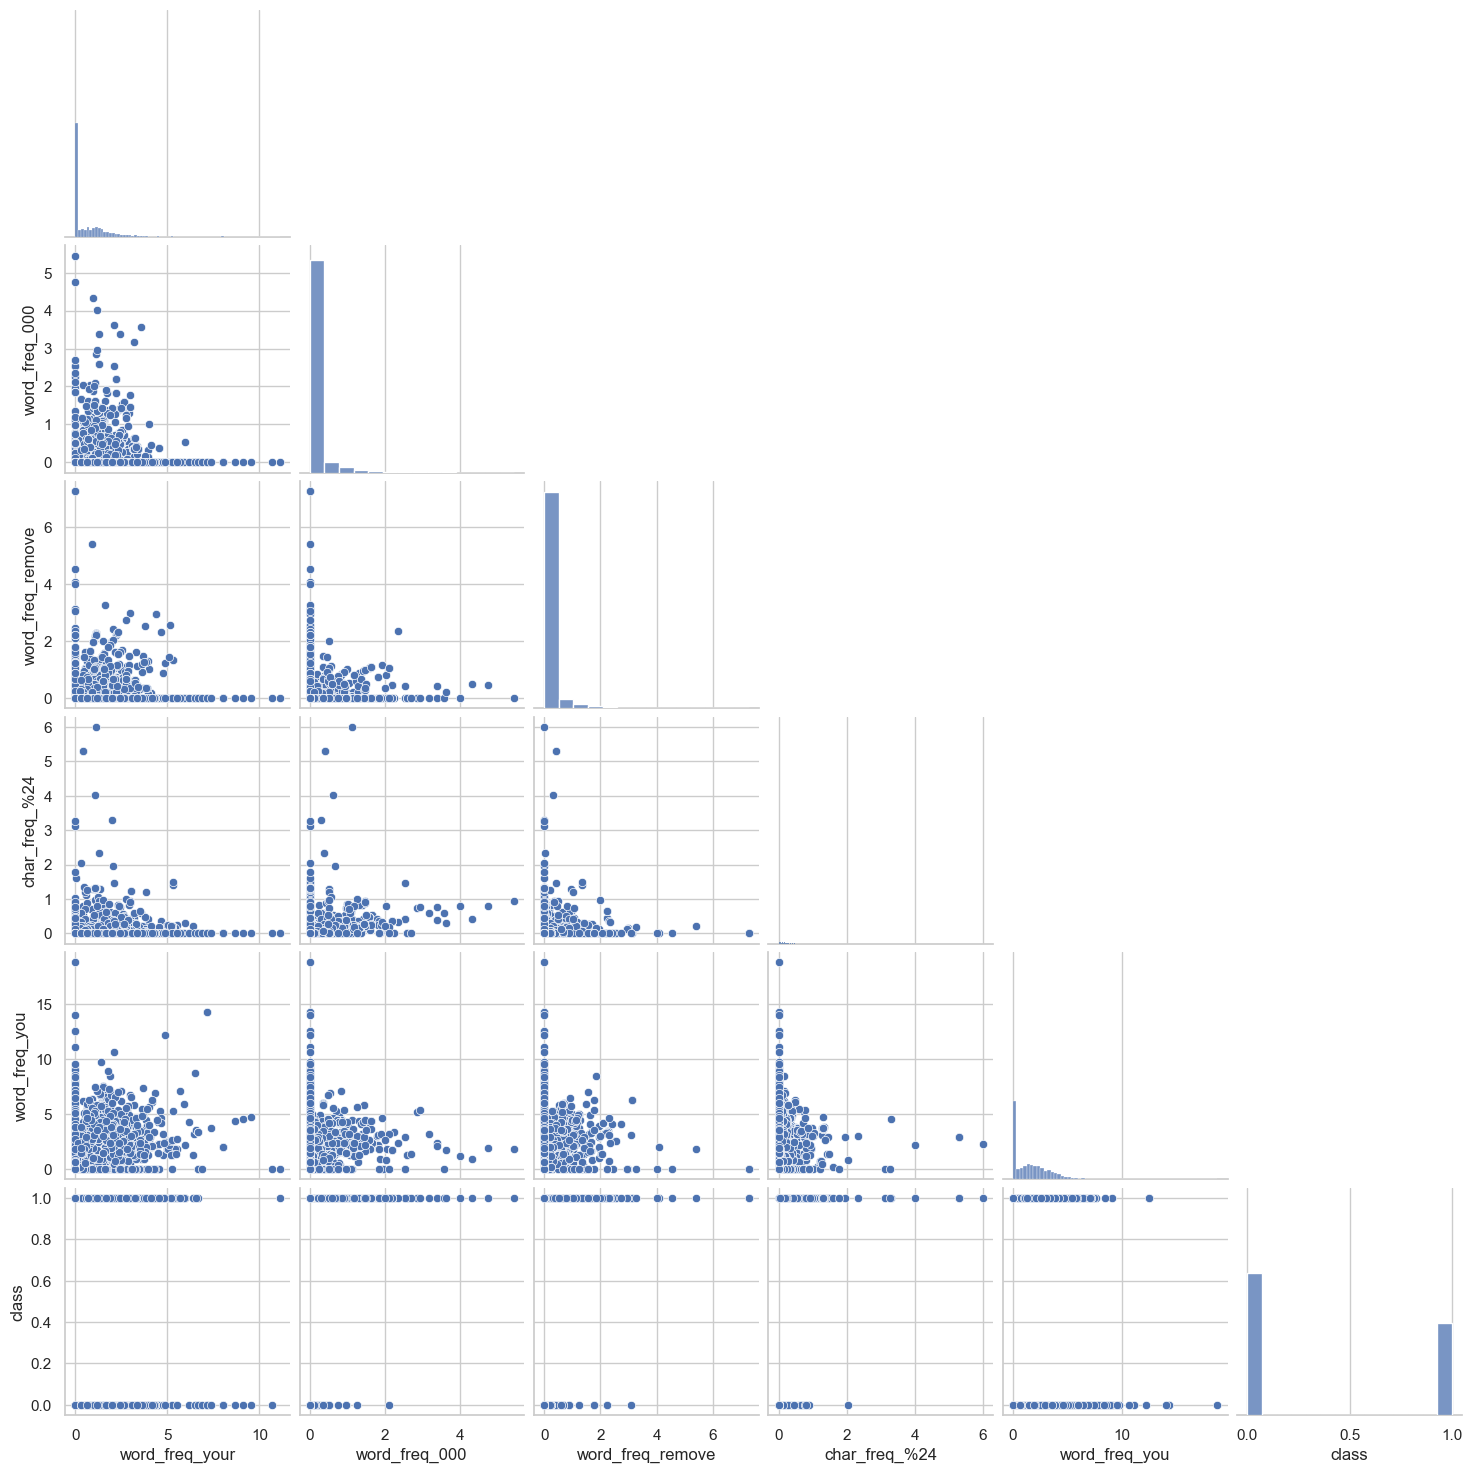


Skewness
word_freq_make                 5.675639
word_freq_address             10.086811
word_freq_all                  3.009249
word_freq_3d                  26.227744
word_freq_our                  4.747126
word_freq_over                 5.956953
word_freq_remove               6.765580
word_freq_internet             9.724848
word_freq_order                5.226067
word_freq_mail                 8.487810
word_freq_receive              5.510250
word_freq_will                 2.867354
word_freq_people               6.955548
word_freq_report              11.754645
word_freq_addresses            6.971041
word_freq_free                10.763594
word_freq_business             5.688642
word_freq_email                5.413754
word_freq_you                  1.591674
word_freq_credit              14.602587
word_freq_your                 2.435527
word_freq_font                 9.975441
word_freq_000                  5.713775
word_freq_money               14.687028
word_freq_hp                  

In [2]:

def _get_important_features(df, target, numeric, max_features):
    """Automatically select important numerical features."""
    numeric = list(numeric)

    if target in numeric:
        try:
            corr = (
                df[numeric]
                .corr()[target]
                .abs()
                .sort_values(ascending=False)
            )
            feats = corr.index.drop(target).tolist()
            return feats[:max_features]
        except Exception:
            pass

    try:
        X = df[numeric].drop(columns=[target], errors="ignore")
        y = df[target]

        if X.shape[1] > 0:
            scores, _ = f_classif(X.fillna(X.median()), y)
            ranking = (
                pd.Series(scores, index=X.columns)
                .sort_values(ascending=False)
            )
            return ranking.head(max_features).index.tolist()

    except Exception:
        pass

    return [c for c in numeric if c != target][:max_features]


def perform_eda(
    df,
    target=None,
    max_features=10,
    pairplot_features=5,
    max_categories=20
):
    """
    Universal EDA Function.

    Parameters
    ----------
    df : pandas.DataFrame
    target : str or None
        Target column name. If None, last column is assumed.
    max_features : int
        Maximum numerical features for plots.
    pairplot_features : int
        Maximum features used in pairplot.
    max_categories : int
        Maximum unique categories for countplots.
    """

    print("=" * 70)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 70)

    if target is None:
        target = df.columns[-1]

    print(f"\nTarget Column : {target}")

    print("\nDataset Shape")
    print(df.shape)

    print("\nColumn Names")
    print(df.columns.tolist())

    print("\nData Types")
    print(df.dtypes)

    print("\nDataset Info")
    df.info()

    print("\nFirst 5 Rows")
    print(df.head())

    print("\nLast 5 Rows")
    print(df.tail())

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nMissing Value Percentage")
    print((df.isnull().sum() / len(df)) * 100)

    print("\nDuplicate Rows :", df.duplicated().sum())

    print("\nUnique Values")
    print(df.nunique())

    print("\nStatistical Summary")
    print(df.describe(include="all"))

    numeric = df.select_dtypes(include=np.number).columns.tolist()
    categorical = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    print("\nNumerical Columns")
    print(numeric)

    print("\nCategorical Columns")
    print(categorical)

    important = _get_important_features(
        df,
        target,
        numeric,
        max_features
    )

    print("\nImportant Features Selected")
    print(important)

    # ---------------------------
    # Class Distribution
    # ---------------------------
    if target in categorical:
        plt.figure(figsize=(6,4))
        sns.countplot(x=df[target])
        plt.title("Target Distribution")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # ---------------------------
    # Histograms
    # ---------------------------
    if important:
        print("\nDistribution Analysis")
        df[important].hist(
            figsize=(15,10),
            bins=20
        )
        plt.tight_layout()
        plt.show()

    # ---------------------------
    # Boxplots
    # ---------------------------
    if important:
        print("\nOutlier Detection")

        for col in important:
            plt.figure(figsize=(6,3))
            sns.boxplot(x=df[col])
            plt.title(col)
            plt.tight_layout()
            plt.show()

    # ---------------------------
    # Heatmap
    # ---------------------------
    if len(important) > 1:
        print("\nCorrelation Heatmap")

        plt.figure(figsize=(10,8))

        sns.heatmap(
            df[important].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f"
        )

        plt.title("Correlation Heatmap")
        plt.tight_layout()
        plt.show()

    # ---------------------------
    # Pairplot
    # ---------------------------
    if len(important) >= 2:

        pair_cols = important[:pairplot_features]

        if target not in pair_cols:
            pair_cols.append(target)

        print("\nPair Plot")

        if target in categorical:

            sns.pairplot(
                df[pair_cols],
                hue=target,
                diag_kind="hist",
                corner=True
            )

        else:

            sns.pairplot(
                df[pair_cols],
                diag_kind="hist",
                corner=True
            )

        plt.show()

    # ---------------------------
    # Target Relationship
    # ---------------------------
    if target in categorical:

        print("\nRelationship with Target")

        for col in important:

            plt.figure(figsize=(6,4))

            sns.boxplot(
                x=df[target],
                y=df[col]
            )

            plt.title(f"{col} vs {target}")

            plt.tight_layout()

            plt.show()

    # ---------------------------
    # Countplots
    # ---------------------------
    if categorical:

        print("\nCategorical Analysis")

        for col in categorical:

            if df[col].nunique() <= max_categories:

                plt.figure(figsize=(6,4))

                sns.countplot(
                    x=df[col],
                    order=df[col].value_counts().index
                )

                plt.xticks(rotation=45)

                plt.title(col)

                plt.tight_layout()

                plt.show()

            else:
                print(f"Skipping '{col}' (>{max_categories} unique categories).")

    # ---------------------------
    # Skewness
    # ---------------------------
    if numeric:
        print("\nSkewness")
        print(df[numeric].skew())

        print("\nKurtosis")
        print(df[numeric].kurt())

    print("\n" + "=" * 70)
    print("EDA COMPLETED SUCCESSFULLY")
    print("=" * 70)

perform_eda(df)    


## Data Preprocessing

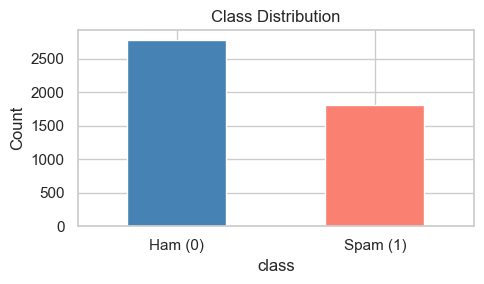

In [3]:
target = df.columns[-1]
X = df.drop(columns=[target])
y = df[target]

imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Class distribution plot
plt.figure(figsize=(5, 3))
y.value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.xticks([0, 1], ['Ham (0)', 'Spam (1)'], rotation=0)
plt.ylabel("Count")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

## Model Training & Evaluation

In [4]:
def evaluate_model(name, model):
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    t1 = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - t1

    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    res = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
        'Training Time': train_time,
        'Prediction Time': pred_time
    }

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])
    axes[0].set_title(f"{name} - Confusion Matrix")

    if y_prob is not None:
        RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
        axes[1].set_title(f"{name} - ROC Curve")
        PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2])
        axes[2].set_title(f"{name} - PR Curve")

    plt.tight_layout()
    plt.show()
    return res

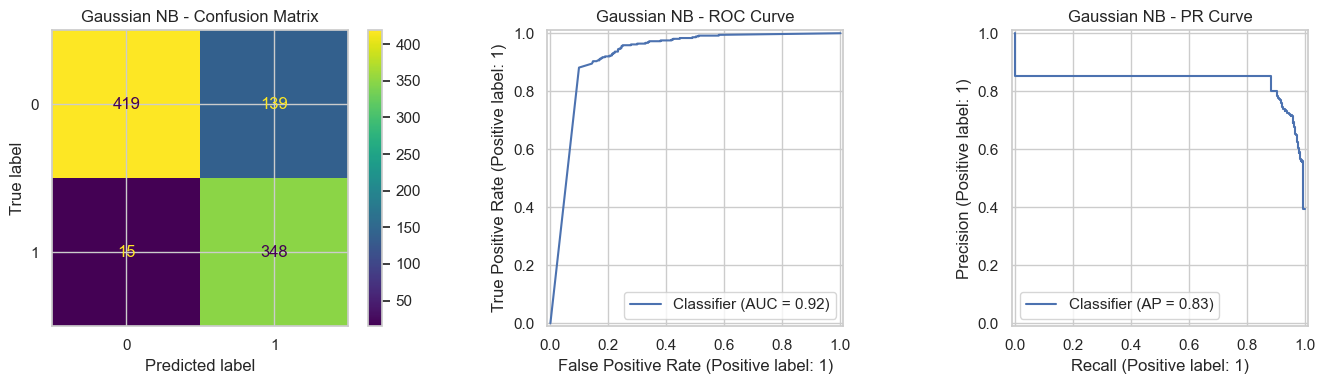

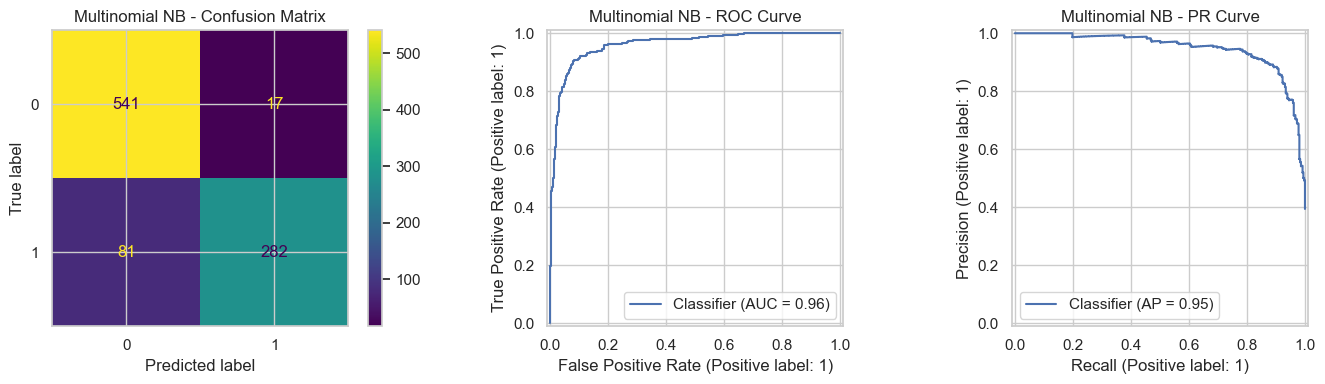

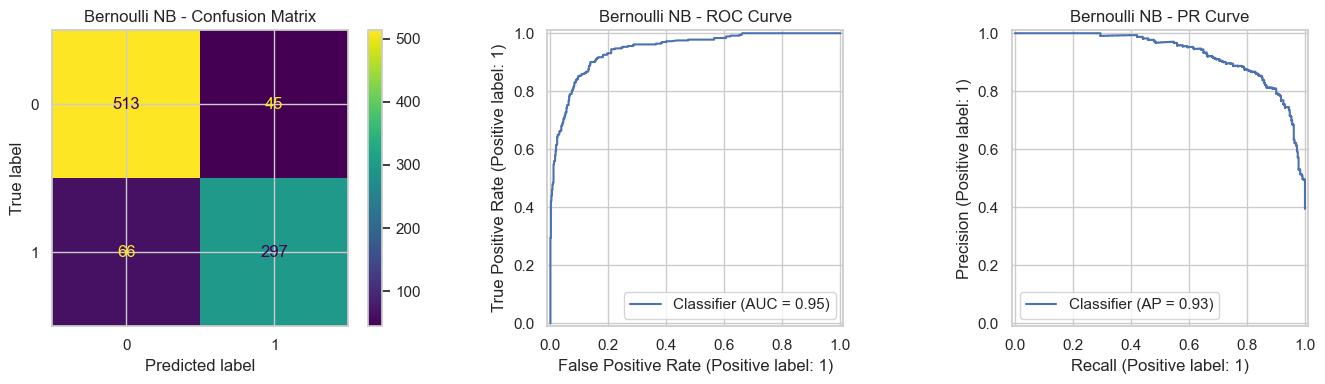

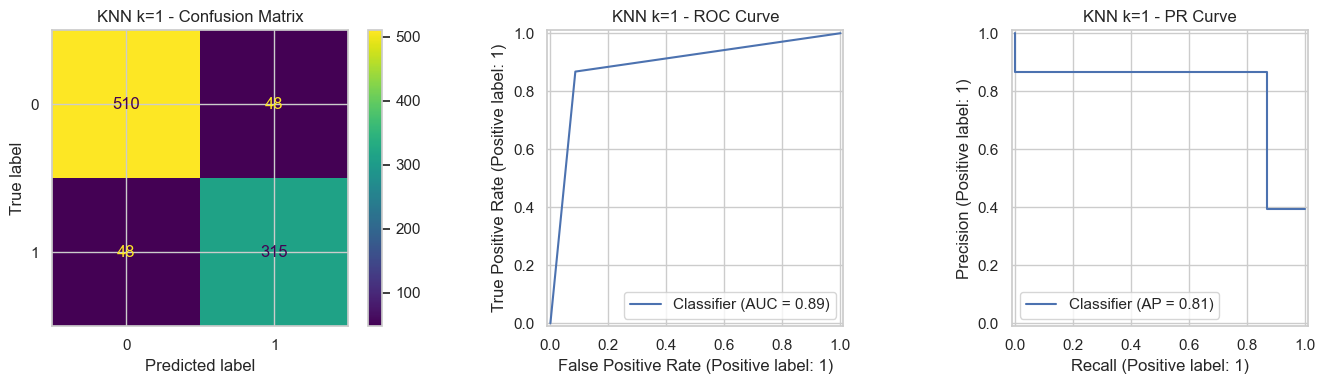

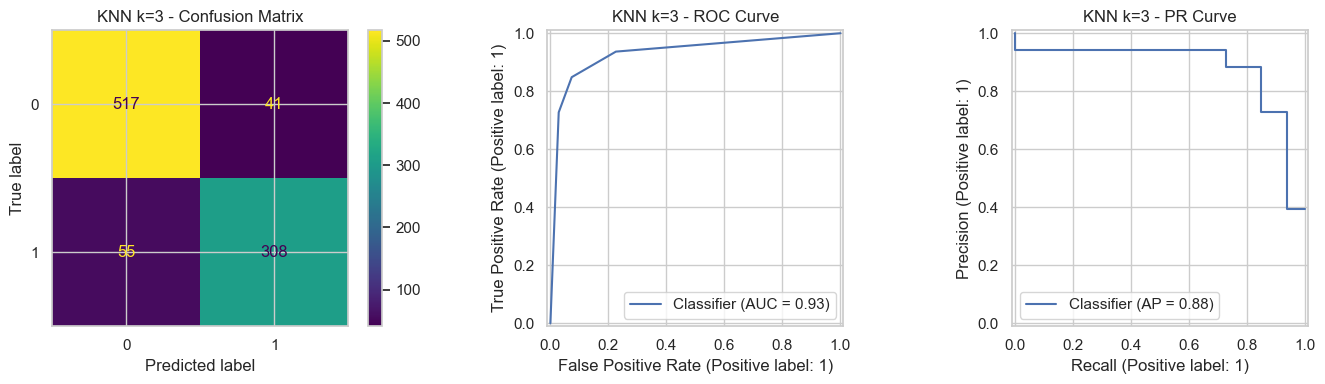

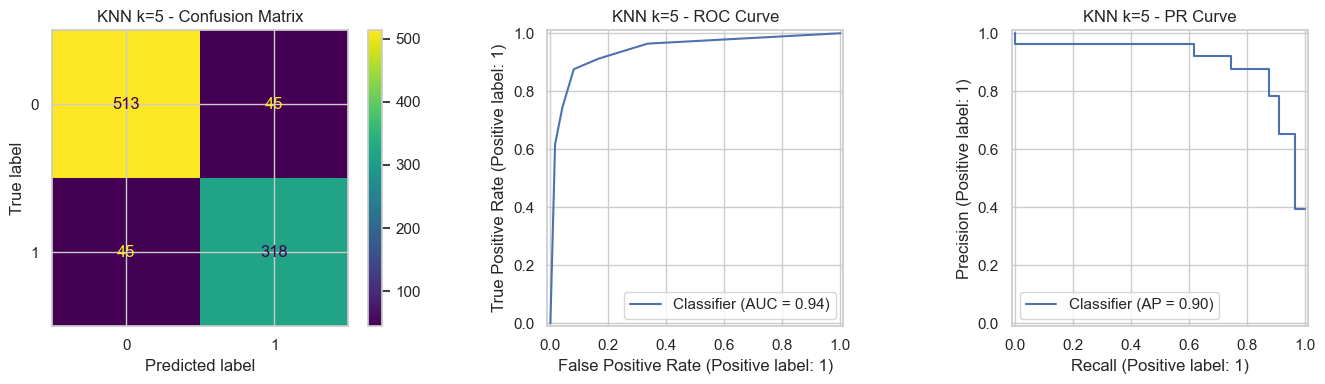

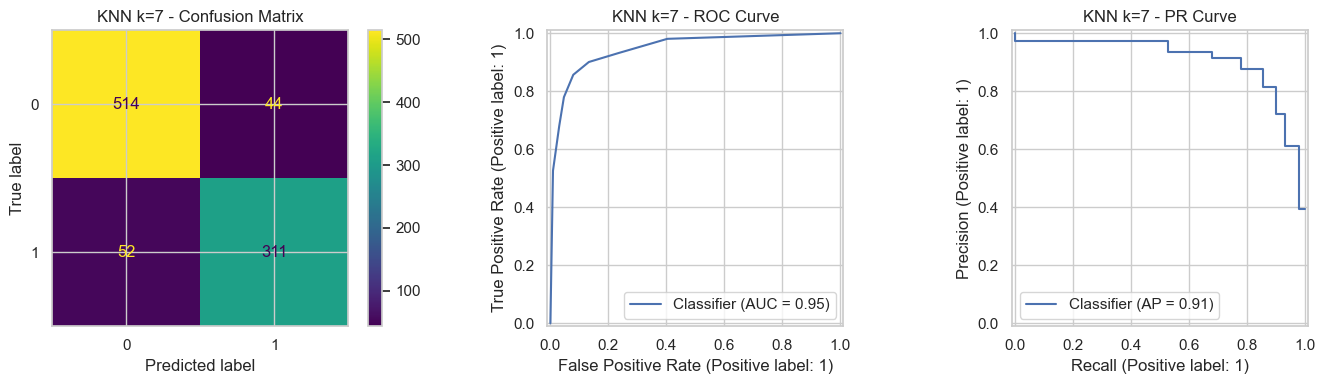

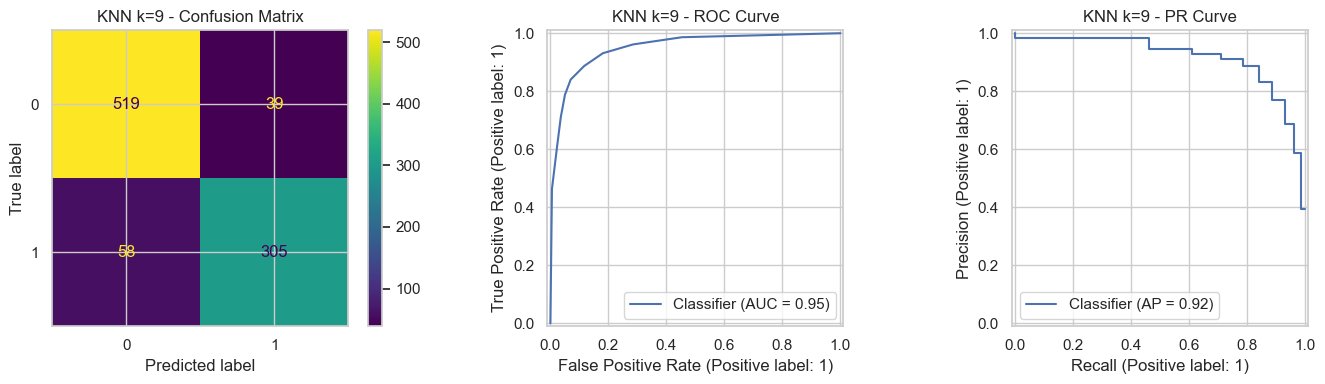

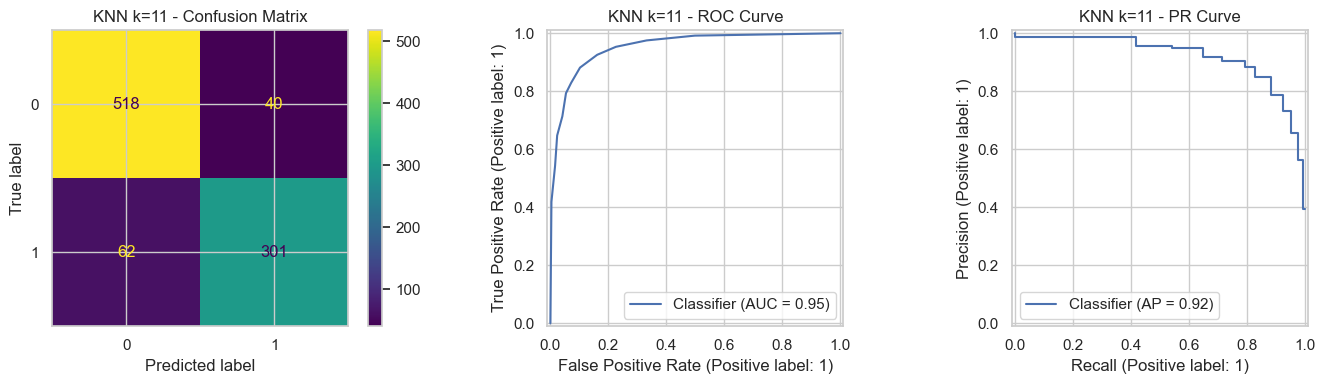

In [5]:
results = []
results.append(evaluate_model("Gaussian NB", GaussianNB()))
results.append(evaluate_model("Multinomial NB", MultinomialNB()))
results.append(evaluate_model("Bernoulli NB", BernoulliNB()))

knn_scores = []
for k in [1, 3, 5, 7, 9, 11]:
    knn_scores.append(evaluate_model(f"KNN k={k}", KNeighborsClassifier(n_neighbors=k)))

## Hyperparameter Tuning

In [6]:
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'algorithm': ['auto', 'kd_tree', 'ball_tree']
}

t0 = time.time()
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)
grid_time = time.time() - t0

t0 = time.time()
rand_search = RandomizedSearchCV(KNeighborsClassifier(),
    {'n_neighbors': randint(1, 12), 'weights': ['uniform', 'distance'],
     'metric': ['euclidean', 'manhattan'], 'algorithm': ['auto', 'kd_tree', 'ball_tree']},
    cv=5, n_iter=20, random_state=42, n_jobs=-1)
rand_search.fit(X_train, y_train)
rand_time = time.time() - t0

print("Grid Best:", grid_search.best_params_, "Score:", round(grid_search.best_score_, 4))
print("Random Best:", rand_search.best_params_, "Score:", round(rand_search.best_score_, 4))

Grid Best: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'} Score: 0.9179
Random Best: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'distance'} Score: 0.9196


## Cross Validation

In [7]:
best_k = grid_search.best_params_['n_neighbors']
cv_nb  = cross_val_score(GaussianNB(), X, y, cv=5)
cv_knn = cross_val_score(KNeighborsClassifier(n_neighbors=best_k), X, y, cv=5)

print("NB CV:", cv_nb, "Mean:", cv_nb.mean().round(4))
print("KNN CV:", cv_knn, "Mean:", cv_knn.mean().round(4))

NB CV: [0.85124864 0.86630435 0.85434783 0.84347826 0.69565217] Mean: 0.8222
KNN CV: [0.86102063 0.88695652 0.91956522 0.90217391 0.76086957] Mean: 0.8661


## KDTree vs BallTree

In [8]:
def time_knn(algo):
    m = KNeighborsClassifier(n_neighbors=best_k, algorithm=algo)
    t0 = time.time(); m.fit(X_train, y_train); tr = time.time() - t0
    t0 = time.time(); p = m.predict(X_test); pr = time.time() - t0
    return accuracy_score(y_test, p), tr, pr

kd_acc, kd_tr, kd_pr   = time_knn('kd_tree')
ball_acc, ball_tr, ball_pr = time_knn('ball_tree')

## Required Tables

In [9]:
# 1. Naive Bayes Comparison
nb_df = pd.DataFrame({
    "Metric":      ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Gaussian":    [results[0][m] for m in ["Accuracy","Precision","Recall","F1","ROC-AUC"]],
    "Multinomial": [results[1][m] for m in ["Accuracy","Precision","Recall","F1","ROC-AUC"]],
    "Bernoulli":   [results[2][m] for m in ["Accuracy","Precision","Recall","F1","ROC-AUC"]],
}).round(4)
display(nb_df)

,Metric,Gaussian,Multinomial,Bernoulli
0,Accuracy,0.8328,0.8936,0.8795
1,Precision,0.7146,0.9431,0.8684
2,Recall,0.9587,0.7769,0.8182
3,F1,0.8188,0.8520,0.8426
4,ROC-AUC,0.9229,0.9625,0.9457


In [10]:
# 2. KNN Comparison
knn_df = pd.DataFrame({
    "k":        [1, 3, 5, 7, 9, 11],
    "Accuracy":  [r['Accuracy']  for r in knn_scores],
    "Precision": [r['Precision'] for r in knn_scores],
    "Recall":    [r['Recall']    for r in knn_scores],
    "F1":        [r['F1']        for r in knn_scores],
}).round(4)
display(knn_df)

,k,Accuracy,Precision,Recall,F1
0,1,0.8958,0.8678,0.8678,0.8678
1,3,0.8958,0.8825,0.8485,0.8652
2,5,0.9023,0.8760,0.8760,0.8760
3,7,0.8958,0.8761,0.8567,0.8663
4,9,0.8947,0.8866,0.8402,0.8628
5,11,0.8893,0.8827,0.8292,0.8551


In [11]:
# 3. GridSearchCV vs RandomizedSearchCV
search_df = pd.DataFrame({
    "Parameter":         ["Best k", "Metric", "Weights", "Algorithm", "CV Accuracy", "Time (s)"],
    "GridSearchCV":      [grid_search.best_params_['n_neighbors'], grid_search.best_params_['metric'],
                          grid_search.best_params_['weights'],     grid_search.best_params_['algorithm'],
                          round(grid_search.best_score_, 4),       round(grid_time, 3)],
    "RandomizedSearchCV":[rand_search.best_params_['n_neighbors'], rand_search.best_params_['metric'],
                          rand_search.best_params_['weights'],     rand_search.best_params_['algorithm'],
                          round(rand_search.best_score_, 4),       round(rand_time, 3)],
})
display(search_df)

,Parameter,GridSearchCV,RandomizedSearchCV
0,Best k,7,8
1,Metric,manhattan,manhattan
2,Weights,distance,distance
3,Algorithm,auto,auto
4,CV Accuracy,0.9179,0.9196
5,Time (s),7.684,1.656


In [12]:
# 4. KDTree vs BallTree
tree_df = pd.DataFrame({
    "Metric":   ["Accuracy", "Training Time (s)", "Prediction Time (s)"],
    "KDTree":   [kd_acc,   kd_tr,   kd_pr],
    "BallTree": [ball_acc, ball_tr, ball_pr],
}).round(6)
display(tree_df)

,Metric,KDTree,BallTree
0,Accuracy,0.895765,0.895765
1,Training Time (s),0.011911,0.002922
2,Prediction Time (s),0.131361,0.097224


In [13]:
# 5. Cross Validation
cv_df = pd.DataFrame({"Fold": list(range(1,6)), "Naive Bayes": cv_nb, "Best KNN": cv_knn}).round(4)
avg   = pd.DataFrame({"Fold":["Average"], "Naive Bayes":[round(cv_nb.mean(),4)], "Best KNN":[round(cv_knn.mean(),4)]})
display(pd.concat([cv_df, avg], ignore_index=True))

,Fold,Naive Bayes,Best KNN
0,1,0.8512,0.8610
1,2,0.8663,0.8870
2,3,0.8543,0.9196
3,4,0.8435,0.9022
4,5,0.6957,0.7609
5,Average,0.8222,0.8661


In [14]:
# 6. Experimental Time Analysis
time_df = pd.DataFrame({
    "Model":           ["Gaussian NB", "Multinomial NB", "Bernoulli NB", "Best KNN"],
    "Training (s)":    [results[0]['Training Time'], results[1]['Training Time'],
                        results[2]['Training Time'], next(r for r in knn_scores if f"k={best_k}" in r['Model'])['Training Time']],
    "Prediction (s)":  [results[0]['Prediction Time'], results[1]['Prediction Time'],
                        results[2]['Prediction Time'], next(r for r in knn_scores if f"k={best_k}" in r['Model'])['Prediction Time']],
}).round(6)
display(time_df)

,Model,Training (s),Prediction (s)
0,Gaussian NB,0.007846,0.004074
1,Multinomial NB,0.005962,0.000624
2,Bernoulli NB,0.002876,0.000784
3,Best KNN,0.001100,0.007580


## Additional Plots

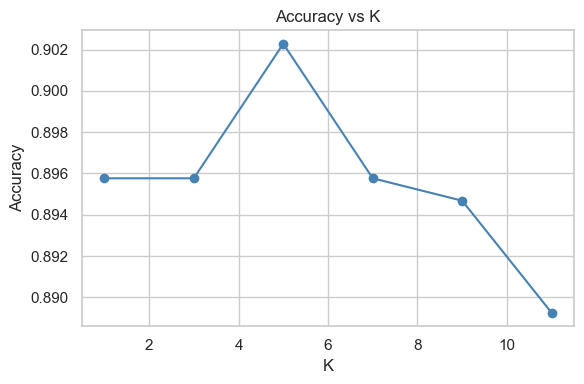

In [15]:
# Accuracy vs K
k_vals = [1, 3, 5, 7, 9, 11]
plt.figure(figsize=(6, 4))
plt.plot(k_vals, [r['Accuracy'] for r in knn_scores], marker='o', color='steelblue')
plt.xlabel('K'); plt.ylabel('Accuracy'); plt.title('Accuracy vs K'); plt.grid(True)
plt.tight_layout(); plt.show()

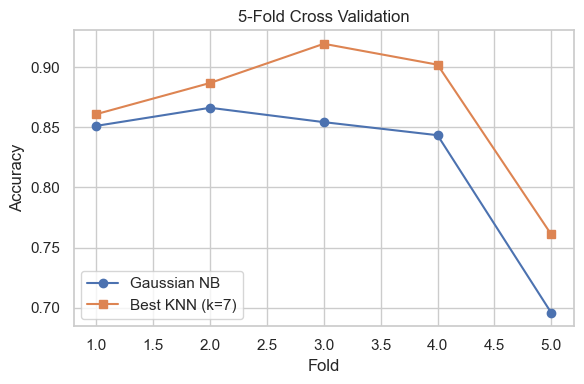

In [16]:
# Cross Validation Accuracy
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1,6), cv_nb,  marker='o', label='Gaussian NB')
ax.plot(range(1,6), cv_knn, marker='s', label=f'Best KNN (k={best_k})')
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy'); ax.set_title('5-Fold Cross Validation')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()

/var/folders/jm/pqwmz8414xd2zxjpxfmdkt_c0000gn/T/ipykernel_13002/3237137567.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_title('Training Time'); ax1.set_xticklabels(time_df['Model'], rotation=20)
/var/folders/jm/pqwmz8414xd2zxjpxfmdkt_c0000gn/T/ipykernel_13002/3237137567.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_title('Prediction Time'); ax2.set_xticklabels(time_df['Model'], rotation=20)


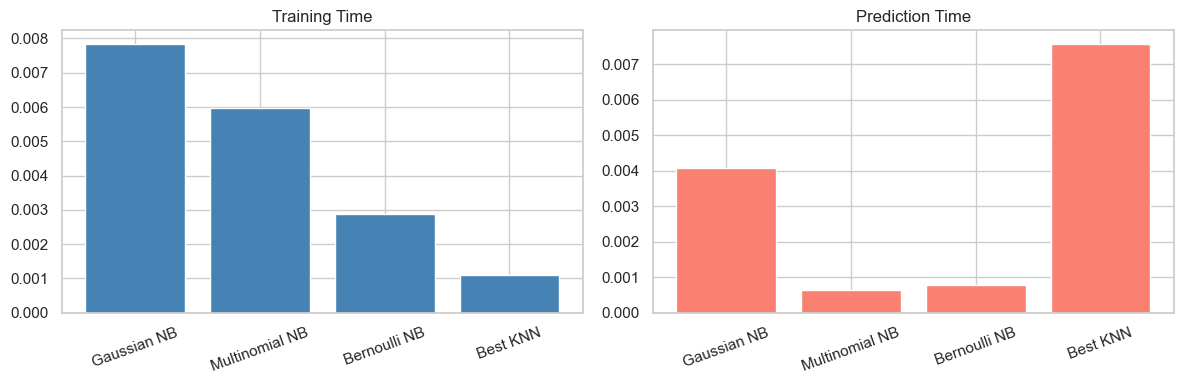

In [17]:
# Training & Prediction Time Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(time_df['Model'], time_df['Training (s)'], color='steelblue')
ax1.set_title('Training Time'); ax1.set_xticklabels(time_df['Model'], rotation=20)
ax2.bar(time_df['Model'], time_df['Prediction (s)'], color='salmon')
ax2.set_title('Prediction Time'); ax2.set_xticklabels(time_df['Model'], rotation=20)
plt.tight_layout(); plt.show()

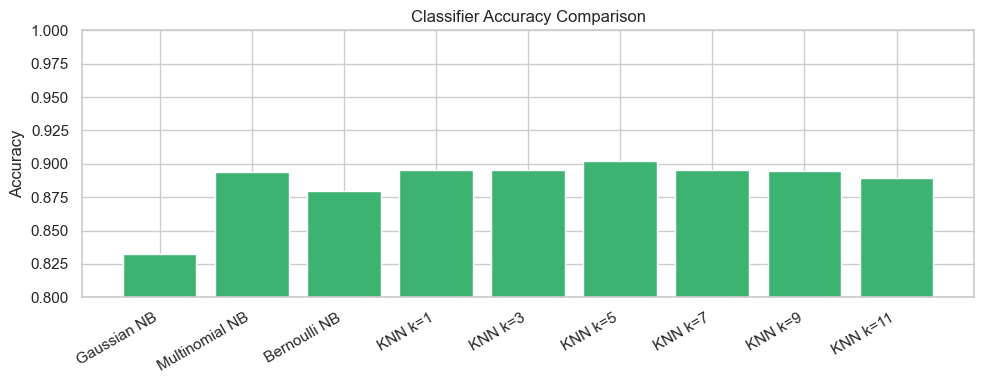

In [18]:
# Classifier Comparison (All models)
all_res = results + knn_scores
names   = [r['Model'] for r in all_res]
accs    = [r['Accuracy'] for r in all_res]
plt.figure(figsize=(10, 4))
bars = plt.bar(names, accs, color='mediumseagreen')
plt.xticks(rotation=30, ha='right'); plt.ylabel('Accuracy'); plt.title('Classifier Accuracy Comparison')
plt.ylim(0.8, 1.0); plt.tight_layout(); plt.show()

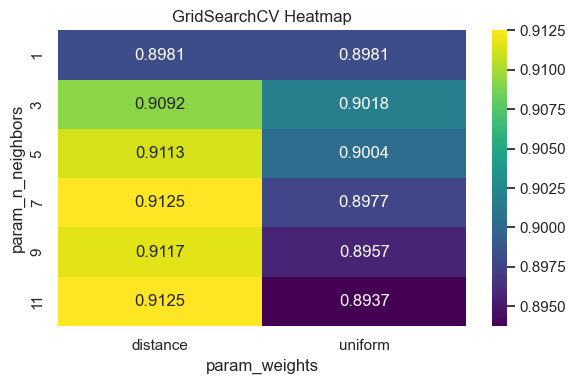

In [19]:
# GridSearchCV Heatmap
grid_res = pd.DataFrame(grid_search.cv_results_)
pivot = grid_res.pivot_table(index='param_n_neighbors', columns='param_weights', values='mean_test_score')
plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap='viridis')
plt.title('GridSearchCV Heatmap'); plt.tight_layout(); plt.show()

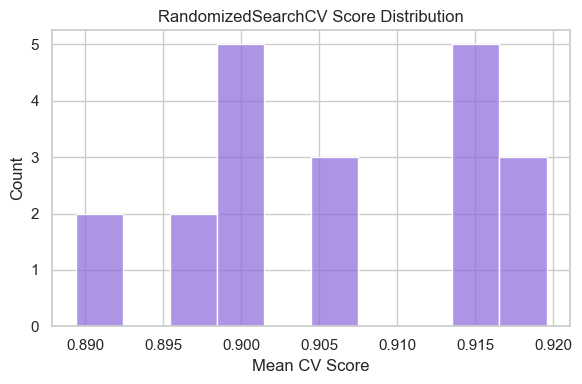

In [20]:
# RandomizedSearchCV Score Distribution
rand_res = pd.DataFrame(rand_search.cv_results_)
plt.figure(figsize=(6, 4))
sns.histplot(rand_res['mean_test_score'], bins=10, color='mediumpurple')
plt.xlabel('Mean CV Score'); plt.title('RandomizedSearchCV Score Distribution')
plt.tight_layout(); plt.show()